# 4f Optical Correlator

Notebook version of `scripts/4f_correlator_example.py`.  We walk through
the physics of a 4f optical correlator that uses a **matched filter** to
locate copies of a target pattern inside a larger scene.

### Outline

1. **Fourier-transforming property of a lens** — how a thin lens +
   free-space propagation produces a spatial Fourier transform.
2. **Sampling-matched focal length** — the constraint that maps the
   discrete grid to a valid physical system.
3. **Matched filter** — why $H = \mathcal{F}^*\{\text{target}\}$ finds the
   target in the scene.
4. **Paraxial approximation** — when the thin-lens model is valid.
5. **Simulation and comparison** — running the physical 4f correlator and
   comparing to a direct FFT cross-correlation.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from fouriax.optics import (
    ComplexMask,
    Field,
    Grid,
    IntensitySensor,
    OpticalModule,
    Spectrum,
    ThinLens,
)
from fouriax.optics.propagation import ASMPropagator

%matplotlib inline

## 1  Fourier-Transforming Property of a Lens

A coherent field $E_{\text{in}}(x)$ placed at the **front focal plane** of
a thin lens of focal length $f$ produces, at the **back focal plane**, the
field

$$
E_{\text{FP}}(x') = \frac{1}{i\lambda f}\,
\int E_{\text{in}}(x)\,
\exp\!\Bigl(-i\,\frac{2\pi}{\lambda f}\,x\,x'\Bigr)\,dx
= \frac{1}{i\lambda f}\;\tilde{E}_{\text{in}}\!\!\left(\frac{x'}{\lambda f}\right).
$$

In words: the output is the **spatial Fourier transform** of the input,
evaluated at spatial frequency $f_x = x'/(\lambda f)$, up to a constant
prefactor.

Crucially, the input must be at the front focal plane — a distance $f$
before the lens — for this to hold *without* a residual quadratic-phase
term.  The complete path for one Fourier-transforming stage is therefore

$$
\boxed{\text{prop}(f) \;\to\; \text{Lens}(f) \;\to\; \text{prop}(f)}
$$

## 2  Sampling-Matched Focal Length

We simulate on a discrete $N \times N$ grid with pixel spacing $\Delta x$.
The highest spatial frequency the grid can represent is
$f_{x,\max} = 1/(2\Delta x)$ (the Nyquist frequency).  At the Fourier
plane, this frequency maps to position

$$
x'_{\max} = \lambda f \, f_{x,\max} = \frac{\lambda f}{2\,\Delta x}.
$$

For the Fourier-plane grid to have the **same pixel spacing** $\Delta x$
and the **same number of samples** $N$, we need

$$
x'_{\max} = \frac{N\,\Delta x}{2}
\qquad\Longrightarrow\qquad
\boxed{f = \frac{n\,N\,\Delta x^2}{\lambda}},
$$

where $n$ is the refractive index of the medium.  This is the
**sampling-matched focal length**.  It guarantees a one-to-one mapping
between the DFT frequency bins and the physical positions at the Fourier
plane.

## 3  The Matched Filter

A 4f system places two Fourier-transforming stages back to back with a
filter mask at the shared Fourier plane:

$$
\text{input}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_1
\;\xrightarrow{\text{prop}(f)}\;
\underbrace{H(f_x, f_y)}_{\text{filter}}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_2
\;\xrightarrow{\text{prop}(f)}\;
\text{output}
$$

Without the filter ($H = 1$), the two Fourier transforms compose to give
a spatially inverted copy of the input — a trivial imaging system.

With a matched filter

$$
H(f_x, f_y) = \tilde{T}^*(f_x, f_y)
= \mathcal{F}^*\{\text{target}\},
$$

the output field becomes (up to constants)

$$
E_{\text{out}} \propto \mathcal{F}^{-1}\!\bigl\{
\tilde{S}(f_x, f_y)\;\tilde{T}^*(f_x, f_y)\bigr\},
$$

which is exactly the **cross-correlation** of the scene $S$ with the
target $T$ (by the correlation theorem).  The output **intensity**
$|E_{\text{out}}|^2$ will show bright peaks wherever the target pattern
appears in the scene.

## 4  Paraxial Validity Constraint

The thin-lens Fourier-transform relationship relies on the **paraxial
approximation**: rays make small angles with the optical axis.  The worst
case is a ray from the edge of the grid ($r_{\max} = N\Delta x / 2$) to
the lens centre, subtending an angle $\theta \approx r_{\max}/f$.

Using the sampling-matched focal length,

$$
\left(\frac{r_{\max}}{f}\right)^{\!2}
= \left(\frac{\lambda}{2\,n\,\Delta x}\right)^{\!2},
$$

which depends only on $\lambda$ and $\Delta x$ — *not* on $N$.  We need
this ratio $\ll 1$ for the paraxial approximation to hold.  Choosing
$\Delta x \gg \lambda/(2n)$ ensures this.

## 5  Simulation Parameters

In [2]:
WAVELENGTH_UM = 0.532       # green light
N_MEDIUM      = 1.0         # vacuum / air
GRID_N        = 128         # spatial samples per side
GRID_DX_UM    = 2.0         # pixel pitch [µm]

grid     = Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = Spectrum.from_scalar(WAVELENGTH_UM)

f_um = N_MEDIUM * grid.nx * grid.dx_um**2 / WAVELENGTH_UM
paraxial_fom = (WAVELENGTH_UM / (2 * N_MEDIUM * GRID_DX_UM)) ** 2

print(f"Sampling-matched focal length: f = {f_um:.1f} µm")
print(f"Paraxial figure of merit (r_max/f)² = {paraxial_fom:.4f}  "
      f"({'good' if paraxial_fom < 0.05 else 'marginal'})")

Sampling-matched focal length: f = 962.4 µm
Paraxial figure of merit (r_max/f)² = 0.0177  (good)


## 6  Build Scene and Target

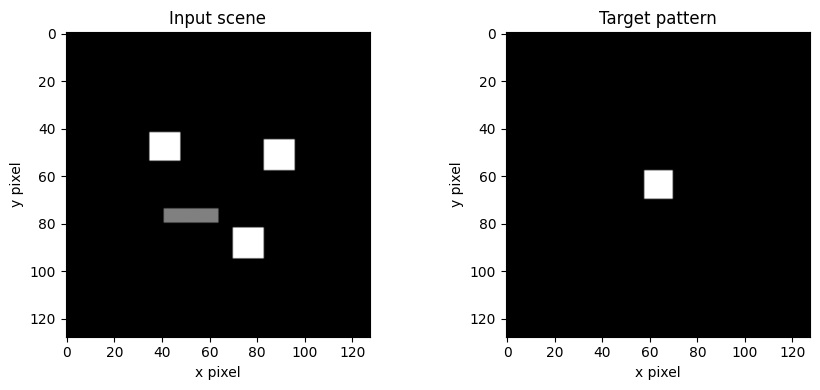

In [3]:
def make_rect(cx_f, cy_f, w_f, h_f):
    """Binary rectangle; positions/sizes are fractions of grid half-extent."""
    half = grid.nx * grid.dx_um / 2.0
    x, y = grid.spatial_grid()
    return ((jnp.abs(x - cx_f*half) <= w_f*half) &
            (jnp.abs(y - cy_f*half) <= h_f*half)).astype(jnp.float32)

# Target: centred square
target = make_rect(0.0, 0.0, 0.10, 0.10)

# Scene: three copies of the target + a distractor rectangle
hw = 0.10
scene = jnp.zeros(grid.shape, dtype=jnp.float32)
for cx, cy in [(-0.35, -0.25), (0.20, 0.38), (0.40, -0.20)]:
    scene = scene + make_rect(cx, cy, hw, hw)
scene = scene + 0.5 * make_rect(-0.18, 0.20, 0.18, 0.05)
scene = jnp.clip(scene, 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(np.asarray(scene), cmap="gray")
axes[0].set_title("Input scene")
axes[1].imshow(np.asarray(target), cmap="gray")
axes[1].set_title("Target pattern")
for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.tight_layout()
plt.show()

## 7  Build the Matched Filter

The matched filter $H = \tilde{T}^*$ is decomposed into amplitude and
phase components for the `ComplexMask` layer:

$$
A(f_x, f_y) = |\tilde{T}| \big/ \max|\tilde{T}|,
\qquad
\phi(f_x, f_y) = -\arg\,\tilde{T}.
$$

The filter is expressed in the centred (``fftshift``) convention because
the physical Fourier plane has DC at the optical axis (array centre).

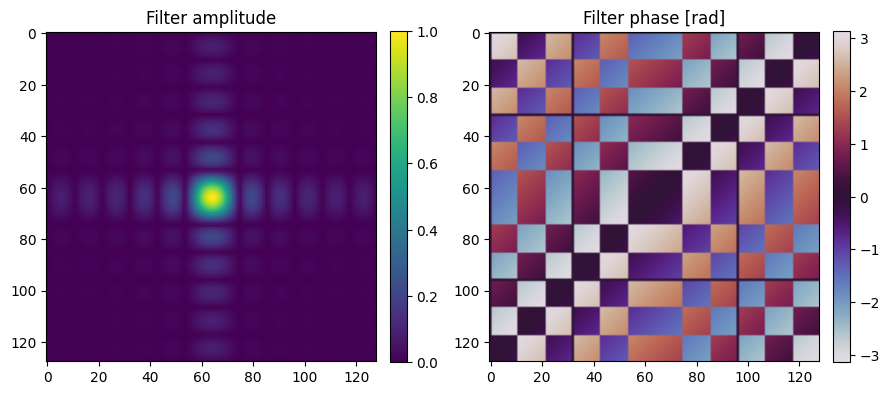

In [4]:
ft_target = jnp.fft.fftshift(
    jnp.fft.fftn(jnp.fft.ifftshift(target), axes=(-2, -1)),
    axes=(-2, -1),
)
amp_filter   = jnp.abs(ft_target) / jnp.max(jnp.abs(ft_target))
phase_filter = -jnp.angle(ft_target)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(np.asarray(amp_filter), cmap="viridis")
axes[0].set_title("Filter amplitude")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
im1 = axes[1].imshow(np.asarray(phase_filter), cmap="twilight",
                      vmin=-np.pi, vmax=np.pi)
axes[1].set_title("Filter phase [rad]")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 8  Assemble and Run the 4f Correlator

The optical system uses `ASMPropagator` (Angular Spectrum Method) with the
sampling planner disabled so that the grid spacing stays exactly matched
to the focal length.

The output is spatially inverted because two successive Fourier transforms
flip the image.  We flip it back for comparison with the ground truth.

In [5]:
prop = ASMPropagator(distance_um=f_um, use_sampling_planner=False,
                     warn_on_regime_mismatch=False)
lens = ThinLens(focal_length_um=f_um)

field_in = Field.plane_wave(grid=grid, spectrum=spectrum).apply_amplitude(
    scene[None, :, :]
)

correlator = OpticalModule(
    layers=(
        prop, lens, prop,                                             # 1st FT stage
        ComplexMask(amplitude_map=amp_filter, phase_map_rad=phase_filter),  # filter
        prop, lens, prop,                                             # 2nd FT stage
    ),
    sensor=IntensitySensor(sum_wavelengths=True),
)

output_4f = np.asarray(correlator.measure(field_in))[::-1, ::-1]  # undo inversion

## 9  Ground Truth: Direct FFT Correlation

In [6]:
f_scene  = jnp.fft.fftn(jnp.fft.ifftshift(scene),  axes=(-2, -1))
f_target = jnp.fft.fftn(jnp.fft.ifftshift(target), axes=(-2, -1))
corr     = jnp.fft.ifftn(f_scene * jnp.conj(f_target), axes=(-2, -1))
output_raw = np.asarray(jnp.abs(jnp.fft.fftshift(corr)) ** 2)

## 10  Compare Results

Pearson correlation between physical 4f and FFT ground truth: ρ = 0.9996


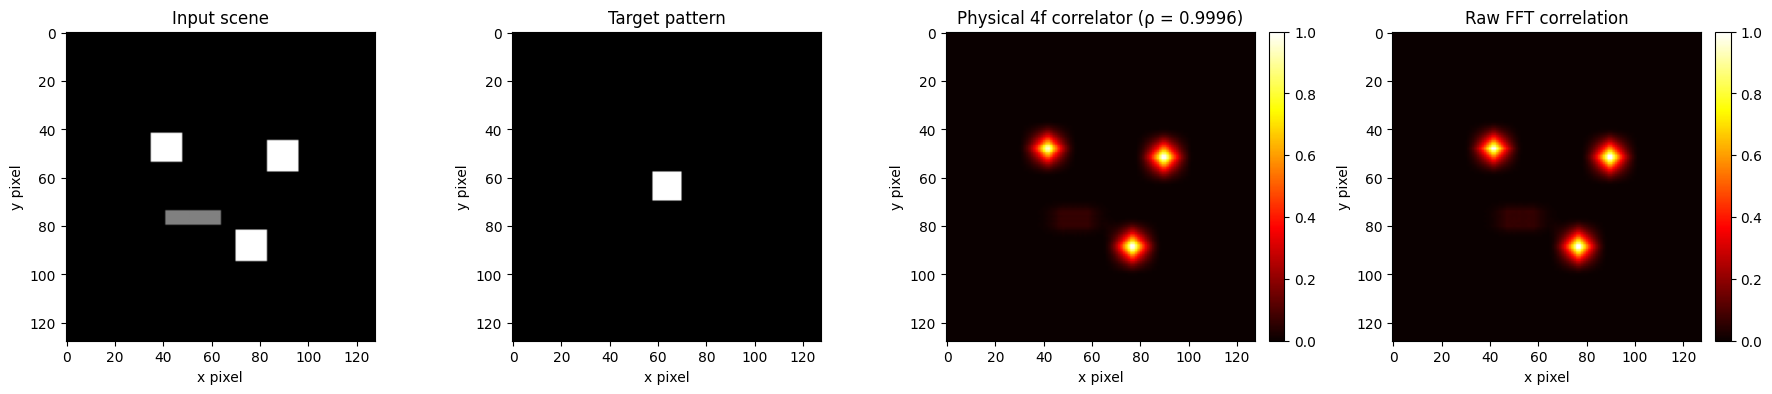

In [7]:
def norm(x):
    return x / np.max(x) if np.max(x) > 0 else x

out_4f_n  = norm(output_4f)
out_raw_n = norm(output_raw)

cc = float(np.corrcoef(out_4f_n.ravel(), out_raw_n.ravel())[0, 1])
print(f"Pearson correlation between physical 4f and FFT ground truth: ρ = {cc:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(np.asarray(scene), cmap="gray")
axes[0].set_title("Input scene")
axes[1].imshow(np.asarray(target), cmap="gray")
axes[1].set_title("Target pattern")

for ax, img, title in zip(
    axes[2:],
    [out_4f_n, out_raw_n],
    [f"Physical 4f correlator (ρ = {cc:.4f})", "Raw FFT correlation"],
    strict=True,
):
    im = ax.imshow(img, cmap="hot")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
fig.tight_layout()
plt.show()